In [15]:
import numpy as np

class MarketSimulator:
    def __init__(self, beta_matrix, competitor_designs, market_size):
       
        self.betas = beta_matrix
        self.comp_designs = competitor_designs
        self.market_size = market_size
        
        # Pre-calculate competitor utilities since they remain constant
        # Resulting matrix: (num_respondents, num_competitors)
        self.comp_utilities = np.dot(self.betas, self.comp_designs.T)

    def evaluate_product(self, our_design, our_price, our_cost, price_betas): #Setup main function with inputs expected 
        """
        Evaluates a new product configuration generated by NSGA-II.
        
        our_design: A 2D array of shape (1, num_attribute_levels)
        our_price: Float representing the product price
        our_cost: Float representing the product cost
        """
        # Calculate utility for our new product
        # Resulting matrix: (num_respondents, 1)
        feature_utility = np.dot(self.betas, our_design.T)

        #Adding Price negativity
        #price_betas shape: (num_respondents, 1)
        price_utilities = price_betas * our_price
        our_utility = feature_utility + price_utilities
        
        # Combine all utilities into a single matrix
        # Resulting matrix: (num_respondents, num_competitors + 1)
        all_utilities = np.hstack((self.comp_utilities, our_utility))
        
        # Apply Multinomial Logit (MNL) rule
        exp_utilities = np.exp(all_utilities)
        probabilities = exp_utilities / np.sum(exp_utilities, axis=1, keepdims=True)
        
        # Extract the probability column for our product (the last column)
        our_probabilities = probabilities[:, -1]
        
        # Calculate final objectives
        market_share = np.mean(our_probabilities)
        unit_sales = market_share * self.market_size
        profit = unit_sales * (our_price - our_cost)
        
        return market_share, profit

In [17]:
# --- Define product attributes here (edit this to change the product structure) ---
# Format: ("Attribute Name", number_of_levels)
attributes = [
    ("Wire Diameter", 3),   # Add attributes here for reference > 1.25mm, 2.00mm, 2.50mm
    ("Amperage",      2),   # Add attributes here for reference > 3A, 5A
    ("Cycles",        2),   # Add attributes here for reference > 50 cycles, 100 cycles
]

# --- Define your competitors ---
# "levels" is a list of which level each attribute is set to (0-indexed)
# Must have one entry per attribute, in the same order
competitors = [
    {"name": "Competitor A", "price": 2.00, "levels": [0, 0, 0]},  # 1.25mm, 3A, 50 cycles
    {"name": "Competitor B", "price": 3.50, "levels": [2, 1, 1]},  # 2.50mm, 5A, 100 cycles
]

# Automatically derive everything else — DO NOT TOUCH !!!
num_levels     = [a[1] for a in attributes]
total_levels   = sum(num_levels)
start_indices  = [sum(num_levels[:i]) for i in range(len(num_levels))]

# Build the competitor matrix from the levels defined above
competitor_matrix = np.zeros((len(competitors), total_levels), dtype=int)
for row, comp in enumerate(competitors):
    for attr_i, level_choice in enumerate(comp["levels"]):
        competitor_matrix[row, start_indices[attr_i] + level_choice] = 1

comp_prices = np.array([[c["price"]] for c in competitors])

print(f"Competitor matrix:\n{competitor_matrix}")
print(f"Competitor prices: {comp_prices.flatten()}")

# Dummy survey
np.random.seed(42) 
num_respondents = 100
dummy_betas = np.random.normal(loc=0.0, scale=1.5, size=(num_respondents, total_levels))

market_size = int(input("Enter the total market size (e.g., 50000): "))
our_price = float(input("Enter our product price in dollars (e.g., 2.50): "))
our_cost = float(input("Enter our product unit cost in dollars (e.g., 0.85): "))

# Generate negative price sensitivities for 100 respondents
# Average sensitivity is -0.8 utility points per dollar
price_betas = np.random.normal(loc=-0.8, scale=0.2, size=(num_respondents, 1))

# Initialize the Simulator
simulator = MarketSimulator(dummy_betas, competitor_matrix, market_size)
# Update the competitor utility calculation to include their prices
# (num_respondents, num_competitors) + (num_respondents, 1) * (1, num_competitors)
simulator.comp_utilities += np.dot(price_betas, comp_prices.T)

# --- Evaluate a single product ---
# Our product: 2.00mm, 5A, 50 cycles -> levels [1, 1, 0]
our_new_design = np.zeros((1, total_levels), dtype=int)
our_levels = [1, 1, 0]
for attr_i, level_choice in enumerate(our_levels):
    our_new_design[0, start_indices[attr_i] + level_choice] = 1

market_share, profit = simulator.evaluate_product(our_new_design, our_price, our_cost, price_betas)

print(f"\nProduct Design String: {our_new_design[0]}")
print(f"Price: ${our_price:.2f} | Cost: ${our_cost:.2f}")
print(f"Calculated Market Share: {market_share * 100:.2f}%")
print(f"Projected Profit: ${profit:,.2f}")

Competitor matrix:
[[1 0 0 1 0 1 0]
 [0 0 1 0 1 0 1]]
Competitor prices: [2.  3.5]


Enter the total market size (e.g., 50000):  50000
Enter our product price in dollars (e.g., 2.50):  3
Enter our product unit cost in dollars (e.g., 0.85):  0.7



Product Design String: [0 1 0 0 1 1 0]
Price: $3.00 | Cost: $0.70
Calculated Market Share: 29.81%
Projected Profit: $34,286.50


In [21]:
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
import numpy as np

class Optimizer(ElementwiseProblem):
    def __init__(self, sim, price_betas, attributes):
        
        # Derive structure from attributes
        self.num_levels    = [a[1] for a in attributes]
        self.total_levels  = sum(self.num_levels)
        self.start_indices = [sum(self.num_levels[:i]) for i in range(len(self.num_levels))]
        self.sim           = sim
        self.price_betas   = price_betas

        # Build bounds dynamically
        # Each attribute variable ranges from 0 to (num_levels - 1)
        # Price is always the last variable, ranging from $1.00 to $5.00
        lower = np.array([0          for n in self.num_levels] + [1.0])
        upper = np.array([n - 1      for n in self.num_levels] + [5.0])

        super().__init__(n_var=len(attributes) + 1, n_obj=2, xl=lower, xu=upper)

    def _evaluate(self, x, out, *args, **kwargs):
        
        # Build the one-hot design vector dynamically
        design = np.zeros((1, self.total_levels))
        
        for i, start in enumerate(self.start_indices):
            chosen_level = int(round(x[i]))
            design[0, start + chosen_level] = 1

        price = x[-1]  # price is always the last variable

        share, profit = self.sim.evaluate_product(design, price, 0.85, self.price_betas)
        out["F"] = [-share, -profit]

# --- Execute and Print ---
res = minimize(Optimizer(simulator, price_betas, attributes), NSGA2(pop_size=100), ('n_gen', 100))

print(f"Found {len(res.F)} optimal solutions:\n" + "-"*45)

for share, profit, price in zip(-res.F[:, 0], -res.F[:, 1], res.X[:, len(attributes)]):
    print(f"Share: {share*100:5.2f}% | Profit: ${profit:8.2f} | Price: ${price:5.2f}")

Found 100 optimal solutions:
---------------------------------------------
Share: 55.03% | Profit: $ 4126.95 | Price: $ 1.00
Share: 55.03% | Profit: $ 4126.95 | Price: $ 1.00
Share: 23.62% | Profit: $35068.20 | Price: $ 3.82
Share: 23.62% | Profit: $35068.20 | Price: $ 3.82
Share: 45.43% | Profit: $19863.53 | Price: $ 1.72
Share: 44.19% | Profit: $21351.46 | Price: $ 1.82
Share: 47.94% | Profit: $16504.37 | Price: $ 1.54
Share: 51.33% | Profit: $11136.93 | Price: $ 1.28
Share: 53.27% | Profit: $ 7629.59 | Price: $ 1.14
Share: 27.00% | Profit: $34572.97 | Price: $ 3.41
Share: 27.76% | Profit: $34324.00 | Price: $ 3.32
Share: 31.35% | Profit: $32480.63 | Price: $ 2.92
Share: 28.85% | Profit: $33883.75 | Price: $ 3.20
Share: 54.33% | Profit: $ 5545.59 | Price: $ 1.05
Share: 32.91% | Profit: $31333.49 | Price: $ 2.75
Share: 32.91% | Profit: $31333.49 | Price: $ 2.75
Share: 24.63% | Profit: $35023.31 | Price: $ 3.69
Share: 44.65% | Profit: $20808.71 | Price: $ 1.78
Share: 29.17% | Profit: $

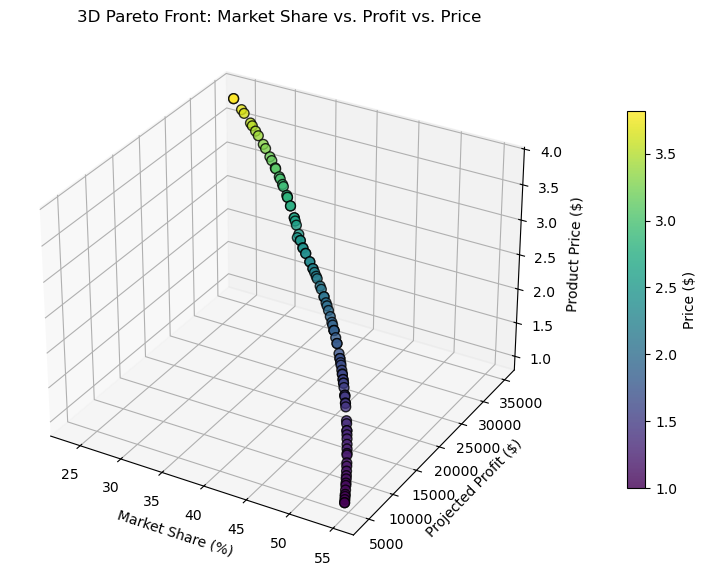

In [22]:
import matplotlib.pyplot as plt

# Extract the final values from your Pymoo results
market_share = -res.F[:, 0] * 100
profit = -res.F[:, 1]
prices = res.X[:, len(attributes)]

# Set up the 3D figure
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Create the 3D scatter plot
# Using a subtle color gradient along the Z-axis (price) for extra clarity
scatter = ax.scatter(market_share, profit, prices, c=prices, cmap='viridis', s=50, alpha=0.8, edgecolors='black')

# Add professional labels and formatting
ax.set_title("3D Pareto Front: Market Share vs. Profit vs. Price")
ax.set_xlabel("Market Share (%)")
ax.set_ylabel("Projected Profit ($)")
ax.set_zlabel("Product Price ($)")

# Add a color bar legend for the exact price values
cbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label("Price ($)")

# Display the interactive 3D graph
plt.show()